Introducción

¿Qué tipo de problemas se pueden resolver con regresión lineal?
La regresión lineal se utiliza para predecir valores numéricos continuos basados en una o más variables independientes.
Ejemplos: predecir ventas, precios de vivienda, temperatura, etc.

In [1]:
# Importa el módulo pandas para trabajar con datos
import pandas as pd

# Obtiene el dataset desde una URL externa
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv

# Lee el archivo CSV descargado y lo carga en un DataFrame de Pandas
bike_data = pd.read_csv("daily-bike-share.csv")

# Muestra las primeras filas para verificar que se haya cargado correctamente
bike_data.head()


--2025-10-16 16:51:21--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48800 (48K) [text/plain]
Saving to: ‘daily-bike-share.csv’

daily-bike-share.cs 100%[===================>]  47.66K  --.-KB/s    in 0.01s   

2025-10-16 16:51:22 (4.04 MB/s) - ‘daily-bike-share.csv’ saved [48800/48800]



,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82


In [2]:


# Muestra las primeras 5 filas del dataset
bike_data.head()
# Muestra información general del dataset
bike_data.info()
# Genera una tabla con la descripción de cada campo y su significado
bike_data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  rentals     731 non-null    int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 80.1+ KB


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000


Pregunta: ¿Qué variable queremos predecir? la variable rentals, que represneta el numero total de bicicletas alquiladas por dia, teniendo en cuenta las otras variables como temperatura, humedad, dia, etc.

In [4]:
# Extrae el día del mes desde la columna de fechas
bike_data["day"] = pd.DatetimeIndex(bike_data["dteday"]).day

# Muestra las primeras 25 filas del dataset
bike_data.head(25)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals,day
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,1
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,2
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,3
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,4
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,5
5,6,1/6/2011,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,6
6,7,1/7/2011,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,7
7,8,1/8/2011,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,8
8,9,1/9/2011,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,9
9,10,1/10/2011,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,10


In [5]:
# Definir las características numéricas relevantes del dataset
feature_cols = ['temp', 'atemp', 'hum', 'windspeed']

X = bike_data[feature_cols]

# Seleccionar la variable objetivo (label)
y = bike_data['rentals']

# Mostrar estadísticas descriptivas de las variables numéricas y el objetivo
print("Características numéricas:")
display(X.describe())

print("\nVariable objetivo:")
display(y.describe())

Características numéricas:


,temp,atemp,hum,windspeed
count,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.627894,0.190486
std,0.183051,0.162961,0.142429,0.077498
min,0.059130,0.079070,0.000000,0.022392
25%,0.337083,0.337842,0.520000,0.134950
50%,0.498333,0.486733,0.626667,0.180975
75%,0.655417,0.608602,0.730209,0.233214
max,0.861667,0.840896,0.972500,0.507463



Variable objetivo:


,rentals
count,731.000000
mean,848.176471
std,686.622488
min,2.000000
25%,315.500000
50%,713.000000
75%,1096.000000
max,3410.000000


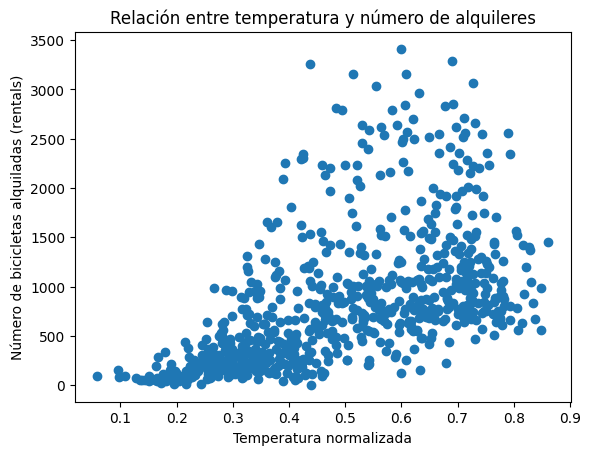

In [6]:
# TODO: Grafica una dispersión de temperatura vs rentals
import matplotlib.pyplot as plt

plt.scatter(bike_data['temp'], bike_data['rentals'])
plt.xlabel('Temperatura normalizada')
plt.ylabel('Número de bicicletas alquiladas (rentals)')
plt.title('Relación entre temperatura y número de alquileres')
plt.show()

Pregunta: ¿Se observa alguna relación lineal? Sí, se observa una relación lineal positiva,
A medida que aumenta la temperatura, también aumenta el número de bicicletas alquiladas.

In [7]:
from sklearn.model_selection import train_test_split

X = bike_data[['temp', 'atemp', 'hum', 'windspeed']]
y = bike_data['rentals']

# Divide los datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Mostrar cuántas filas tiene cada conjunto
print("Tamaño del conjunto de entrenamiento:", X_train.shape[0])
print("Tamaño del conjunto de prueba:", X_test.shape[0])

Tamaño del conjunto de entrenamiento: 511
Tamaño del conjunto de prueba: 220


Pregunta: ¿Qué pasa si usamos un test_size demasiado pequeño? Un test_size muy pequeño no tendra suficientes datos para evaluar correctamente el modelo, haria una evaluacion poco precisa

In [8]:
from sklearn.linear_model import LinearRegression

# TODO: Crea y entrena el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Muestra los coeficientes βn
print("Intercepto (β0):", model.intercept_)
print("Coeficientes (βn):", model.coef_)

# Muestra información del modelo entrenadoo:
print("\nEcuación del modelo:")
print(f"rentals = {model.intercept_:.2f} + ({model.coef_[0]:.2f})*temp + ({model.coef_[1]:.2f})*atemp + ({model.coef_[2]:.2f})*hum + ({model.coef_[3]:.2f})*windspeed")


Intercepto (β0): 468.4262644184328
Coeficientes (βn): [ 1569.97528715   485.13296453  -617.30980711 -1290.73768019]

Ecuación del modelo:
rentals = 468.43 + (1569.98)*temp + (485.13)*atemp + (-617.31)*hum + (-1290.74)*windspeed


 Pregunta: ¿Cómo interpretas el coeficiente asociado a la temperatura?: El coeficiente de temp representa el cambio en la cantidad de bicicletas alquiladas cuando la temperatura aumenta una unidad, manteniendo constantes las demás variables.

MSE: 354378.074132505
RMSE: 595.2966270125381


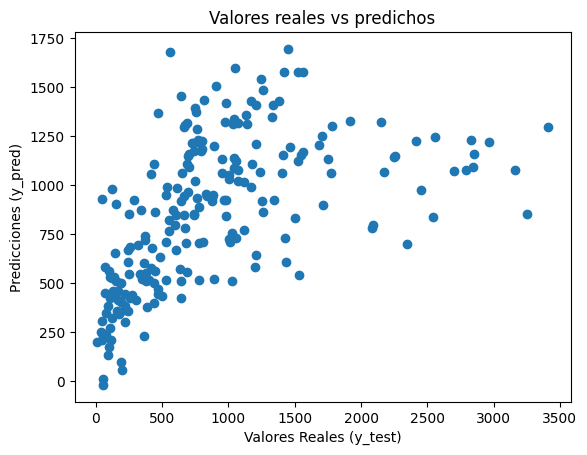

In [9]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Genera predicciones
y_pred = model.predict(X_test)

# Calcula métrica MSE (Error cuadrático medio)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# Calcula RMSE (Raíz del MSE)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

# Grafica valores reales vs predichos
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reales (y_test)")
plt.ylabel("Predicciones (y_pred)")
plt.title("Valores reales vs predichos")
plt.show()


Pregunta: ¿Qué información nos da el MSE sobre la calidad del modelo?
MSE indica cuanto se equivoca en promedio el modelo, un valor menor significa mayor precisión.
 Pregunta: ¿Qué información nos da el RMSE sobre la calidad del modelo? RMSE mide el error promedio en las mismas unidades que la variable objetivo, cuanto mas bajo, mayor precisión del modelo.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Solo temperatura
X_temp = bike_data[['temp']]
y = bike_data['rentals']


X_train, X_test, y_train, y_test = train_test_split(X_temp, y, test_size=0.3, random_state=0)

model_temp = LinearRegression()
model_temp.fit(X_train, y_train)

y_pred_temp = model_temp.predict(X_test)

mse_temp = mean_squared_error(y_test, y_pred_temp)
rmse_temp = np.sqrt(mse_temp)
r2_temp = r2_score(y_test, y_pred_temp)

print("MSE (solo temp):", mse_temp)
print("RMSE (solo temp):", rmse_temp)
print("R² (solo temp):", r2_temp)


MSE (solo temp): 374482.8022842907
RMSE (solo temp): 611.9499998237525
R² (solo temp): 0.26584997002643684


Pregunta: ¿Cuál modelo es más preciso y por qué?
El modelo multivariable es mas preciso porque utiliza mas información relevante para predecir la variable objetivo, reduciendo errores y mejorando el modelo.

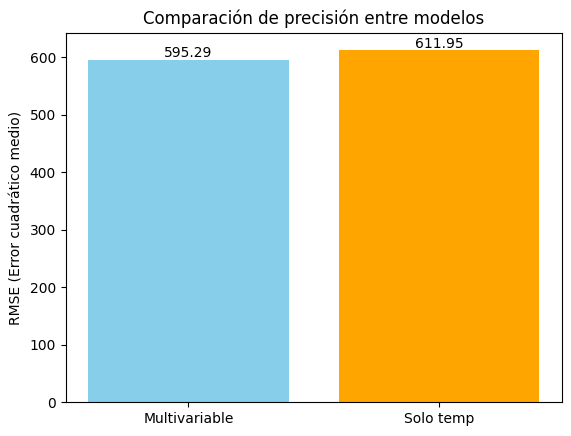

In [11]:
import matplotlib.pyplot as plt

# Resultados obtenidos
rmse_multi = 595.29
rmse_temp = 611.95

# Comparación
plt.bar(['Multivariable', 'Solo temp'], [rmse_multi, rmse_temp], color=['skyblue', 'orange'])
plt.title('Comparación de precisión entre modelos')
plt.ylabel('RMSE (Error cuadrático medio)')
plt.text(0, rmse_multi + 5, f'{rmse_multi:.2f}', ha='center')
plt.text(1, rmse_temp + 5, f'{rmse_temp:.2f}', ha='center')
plt.show()
